In [1]:
#Customer Segmentation Project
import numpy as np
import pandas as pd
import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

In [2]:
# Load the data and do the exploratory data analysis
customer_data = pd.read_csv("marketing_campaign.csv", sep="\t")
print("Number of records:", len(customer_data))
customer_data.head()

Number of records: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
customer_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [5]:
# Categorical Variable levels
print("Marital_Status:\n", customer_data["Marital_Status"].value_counts(), "\n")
print("Education:\n", customer_data["Education"].value_counts())

Marital_Status:
 Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Education:
 Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [6]:
# Drop missing data points
customer_data = customer_data.dropna()
print("The total number of recrds after removing the rows with missing values:", len(customer_data))

The total number of recrds after removing the rows with missing values: 2216


In [7]:
# date time formatting
customer_data["Dt_Customer"] = pd.to_datetime(customer_data["Dt_Customer"], format='%d-%m-%Y')

In [8]:
# Feature Engineering Steps

In [9]:
dates = []
for i in customer_data["Dt_Customer"]:
    i = i.date()
    dates.append(i)  
#Dates of the newest and oldest recorded customer
print("The newest customer's enrolment date in therecords:",max(dates))
print("The oldest customer's enrolment date in the records:",min(dates))

The newest customer's enrolment date in therecords: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30


In [10]:
# Create a feature "Tenure"
days = []
d1 = max(dates) # compare with the newest customer date
for i in dates:
    delta = d1 - i
    days.append(delta.days)
customer_data["Tenure"] = days
customer_data["Tenure"] = pd.to_numeric(customer_data["Tenure"], errors="coerce")


In [11]:
#Create "Age" at 2012
customer_data["Age"] = 2012- customer_data["Year_Birth"]


In [12]:
#Remove outliers by setting a cap on Age and income. 

customer_data = customer_data[(customer_data["Age"]<100)]
customer_data = customer_data[(customer_data["Income"]<600000)]
print("The total number of recrds after removing the routliers:", len(customer_data))

The total number of recrds after removing the routliers: 2212


In [13]:
#Total spend on all items
customer_data["Spent"] = customer_data["MntWines"]+ \
                         customer_data["MntFruits"]+ \
                         customer_data["MntMeatProducts"]+ \
                         customer_data["MntFishProducts"]+ \
                         customer_data["MntSweetProducts"]+ \
                         customer_data["MntGoldProds"]



In [14]:
# living situation by marital status "Alone" vs "Partner"
customer_data["Living_With"]=customer_data["Marital_Status"].\
                             replace({"Married":"Partner", "Together":"Partner",\
                                      "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone",\
                                      "Divorced":"Alone", "Single":"Alone",})

In [15]:
#total children living in the household
customer_data["Children"]=customer_data["Kidhome"]+customer_data["Teenhome"]

# total members in the householde
customer_data["Family_Size"] = customer_data["Living_With"].\
                               replace({"Alone": 1, "Partner":2})+ customer_data["Children"]
# parenthood
customer_data["Parent"] = np.where(customer_data.Children> 0, 1, 0)

In [16]:
#Segmenting education levels in three groups
customer_data["Education"]=customer_data["Education"].\
                           replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", \
                                    "Graduation":"Graduate", "Master":"Postgraduate",\
                                    "PhD":"Postgraduate"})

In [17]:
# drop  the redundant features
to_drop = ["Marital_Status",  "Year_Birth", "ID", "Z_CostContact","Z_Revenue", "Dt_Customer"]
customer_data = customer_data.drop(to_drop, axis=1)

In [18]:
customer_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2212.0,51958.810579,21527.278844,1730.0,35233.5,51371.0,68487.00,162397.0
Kidhome,2212.0,0.441682,0.536955,0.0,0.0,0.0,1.00,2.0
Teenhome,2212.0,0.505877,0.544253,0.0,0.0,0.0,1.00,2.0
Recency,2212.0,49.019439,28.943121,0.0,24.0,49.0,74.00,99.0
MntWines,2212.0,305.287523,337.322940,0.0,24.0,175.5,505.00,1493.0
MntFruits,2212.0,26.329566,39.744052,0.0,2.0,8.0,33.00,199.0
MntMeatProducts,2212.0,167.029837,224.254493,0.0,16.0,68.0,232.25,1725.0
MntFishProducts,2212.0,37.648734,54.772033,0.0,3.0,12.0,50.00,259.0
MntSweetProducts,2212.0,27.046564,41.090991,0.0,1.0,8.0,33.00,262.0
MntGoldProds,2212.0,43.925859,51.706981,0.0,9.0,24.5,56.00,321.0


<Axes: >

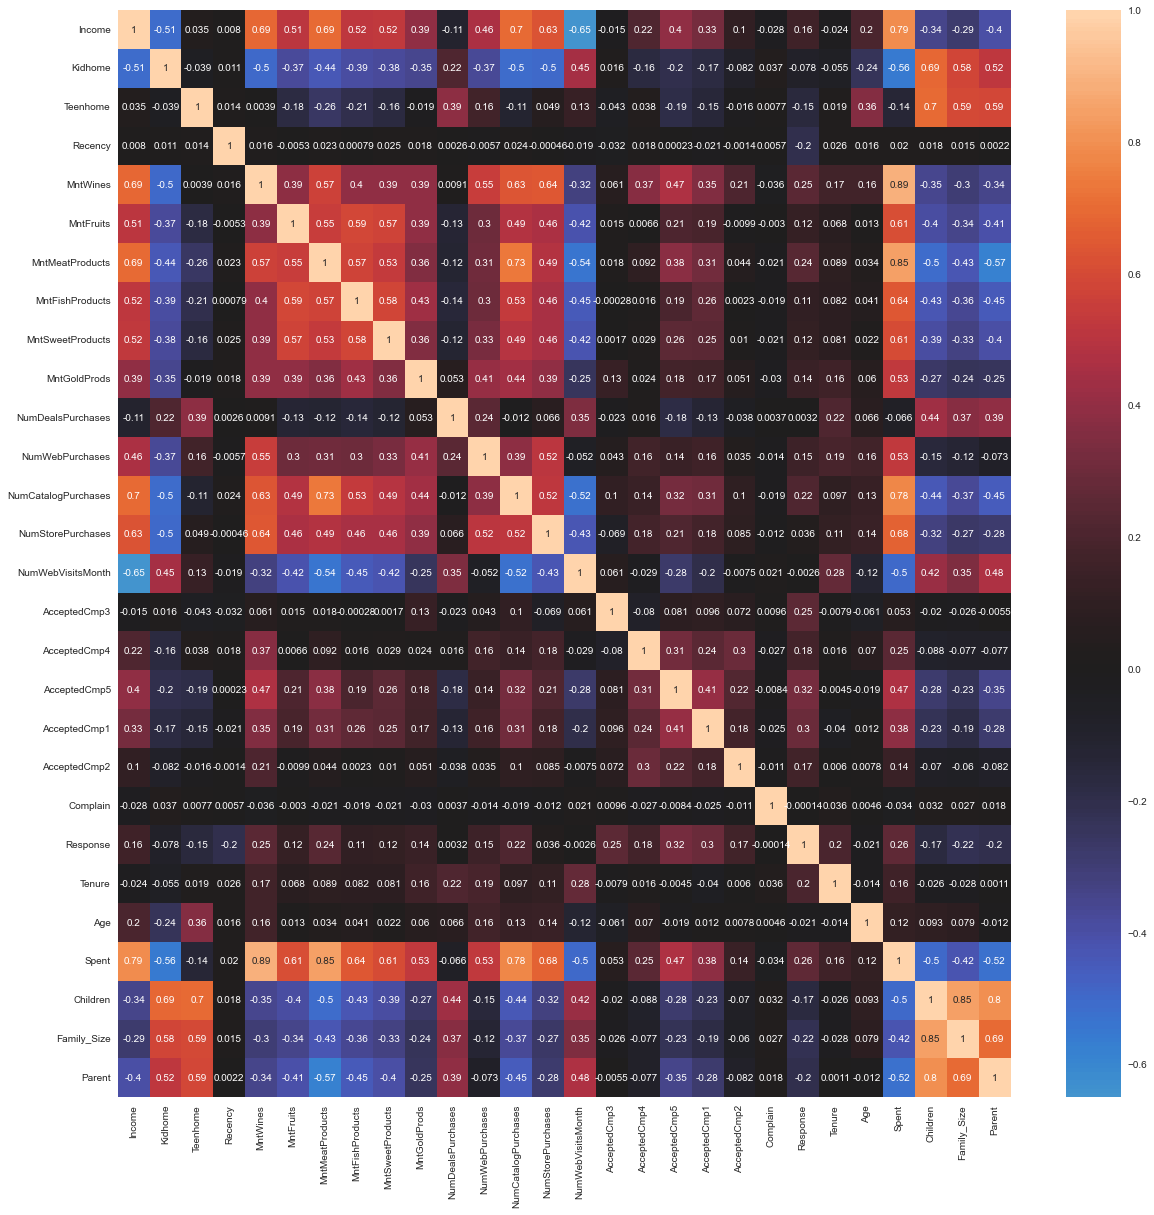

In [19]:
# only numerical values
to_drop = ["Education",  "Living_With"]
customer_data_num= customer_data.drop(to_drop, axis=1)

#correlation matrix
corrmat= customer_data_num.corr()
plt.figure(figsize=(20,20))  
sns.heatmap(corrmat,annot=True, center=0)

In [20]:
# Save a copy of the data for profiling before encoding categories
customer_data_copy=customer_data
# Encode all categorical features
#Label Encoding the object dtypes.
LE=LabelEncoder()
for i in ['Education', 'Living_With']:
    customer_data[i]=customer_data[[i]].apply(LE.fit_transform)


In [21]:
# Scale and save in a new data frame scaled_df
scaler = StandardScaler()
scaler.fit(customer_data)
scaled_df = pd.DataFrame(scaler.transform(customer_data),columns= customer_data.columns )
scaled_df.head()

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,Complain,Response,Tenure,Age,Spent,Living_With,Children,Family_Size,Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,-0.117256,-0.09552,2.375425,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.117256,-0.09552,-0.420977,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.117256,-0.09552,-0.420977,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.117256,-0.09552,-0.420977,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,-0.117256,-0.09552,-0.420977,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


In [22]:
# PCA for dimensionality reduction
#Initiating PCA to reduce dimentions aka features to 3
pca = PCA(n_components=3)
pca.fit(scaled_df)
PCA_df = pd.DataFrame(pca.transform(scaled_df), columns=(["column1","column2", "column3" ]))
PCA_df.describe().T

,count,mean,std,min,25%,50%,75%,max
column1,2212.0,1.798842e-16,2.960584,-5.924192,-2.556963,-0.861998,2.264130,8.537417
column2,2212.0,-6.424437e-17,1.717093,-4.160004,-1.348776,-0.159793,1.248695,6.063757
column3,2212.0,-2.409164e-17,1.389399,-3.181658,-0.782672,-0.161458,0.406984,8.246967


Elbow Method for PCA data set:


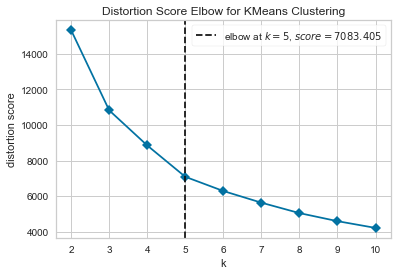

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [23]:
# Elbow method to find numbers of clusters (based on PCA_df)
print('Elbow Method for PCA data set:')
Elbow_M = KElbowVisualizer(KMeans(random_state=42),k=10, timings=False)
Elbow_M.fit(PCA_df)
Elbow_M.show()

In [24]:
#Initiating the Agglomerative Clustering model 
AC = AgglomerativeClustering(n_clusters=5)
# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_df)
PCA_df["Clusters"] = yhat_AC
#Adding the Clusters feature to the orignal dataframe.
customer_data["Clusters"]= yhat_AC
customer_data_copy["Clusters"]= yhat_AC

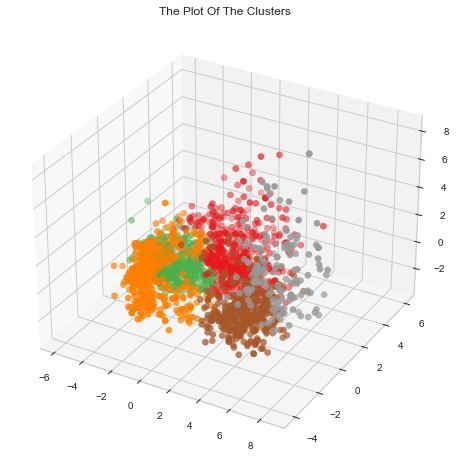

In [25]:
from matplotlib import cm
tab20_5 = cm.get_cmap("Set1", lut = 5)
x =PCA_df["column1"]
y =PCA_df["column2"]
z =PCA_df["column3"]
#Plotting the clusters

fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")

ax.scatter(x, y, z, s=40, c=PCA_df["Clusters"], marker='o' ,  cmap=tab20_5)
ax.set_title("The Plot Of The Clusters")
plt.show()

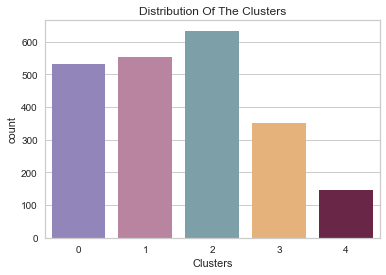

In [26]:
# countplot of clusters
#Plotting countplot of clusters
pal = ["#8E7CC3", "#C27BA0","#76A5AF", "#f6b26b", "#741b47"]


pl = sns.countplot(x=customer_data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

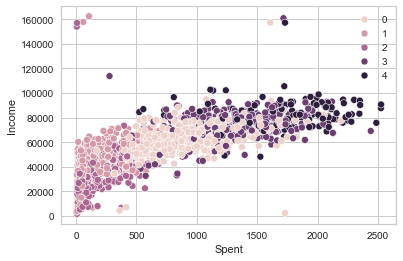

In [27]:
l = sns.scatterplot(data = customer_data,x=customer_data["Spent"], \
                    y=customer_data["Income"],hue=customer_data["Clusters"])
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

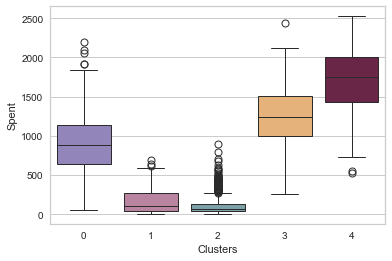

In [28]:
plt.figure()
pl=sns.boxplot(x=customer_data["Clusters"], y=customer_data["Spent"], palette=pal)
plt.show()

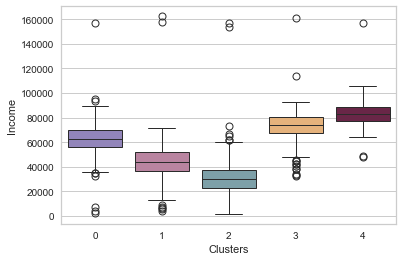

In [29]:
plt.figure()
pl=sns.boxplot(x=customer_data["Clusters"], y=customer_data["Income"], palette=pal)
plt.show()

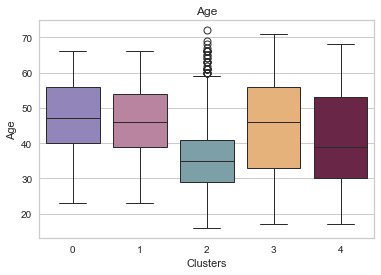

In [30]:

plt.figure()
pl=sns.boxplot(y=customer_data["Age"],x=customer_data["Clusters"], palette=pal)
pl.set_title("Age")
plt.show()

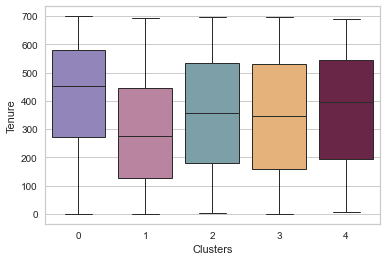

In [31]:
plt.figure()
pl=sns.boxplot(x=customer_data["Clusters"], y=customer_data["Tenure"], palette=pal)
plt.show()

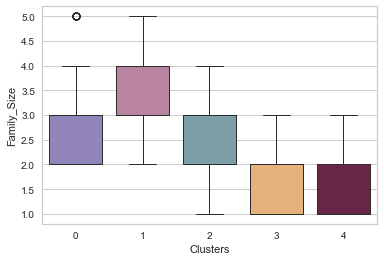

In [32]:
plt.figure()
pl=sns.boxplot(x=customer_data["Clusters"], y=customer_data["Family_Size"], palette=pal)
plt.show()

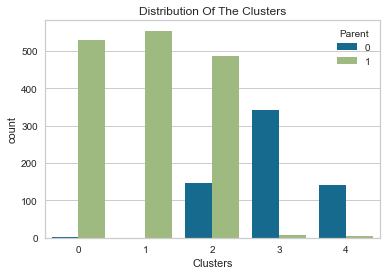

In [33]:

pl = sns.countplot(x=customer_data["Clusters"], hue=customer_data["Parent"])
pl.set_title("Distribution Of The Clusters")
plt.show()

In [34]:
df=customer_data.groupby("Clusters").median()
#df["MntFishProducts"]
#df["Tenure"]